# Qubit data loading

## Introduction

Simple tool to load the qubit measurement data, which is still under the developement phase.

## Function update

20241007: Add notes and plot functions

# Connect to google sheet

In [ ]:
# No need to change this section.
import pandas as pd

# package authernticating Google services
from google.colab import auth
import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe

# autherize Google account and the google sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# id is the unique permenent link of the data sheet name
# regiestered sheet to all the meausrment result
# and select the workseet name "register"
main_url = 'https://docs.google.com/spreadsheets/d/18B2GsZbYBrB5UoGLzjrXGffLZeN21hyk_53EhEkQLEA/edit?gid=0#gid=0'


# print(df)

## Select sheet name

In [ ]:
sheet_name = "register"
group_col = "Column 9"

print(f"Sheet {sheet_name}")
select_sheet = gc.open_by_url(main_url).worksheet(sheet_name)

# Get all data as a DataFrame
df = get_as_dataframe(select_sheet)
df = df.dropna(how='all') # Clean NaN

#display the

grouped_sheet = df.groupby(group_col)
# dfs = {group_name: grouped_df for group_name, grouped_df in df.groupby(group_col)}
for key, df in grouped_sheet:
  print(key, df)

Sheet register
2FQ1FC_L_TSRI163_17              sheet name                                          sheet url  \
43  2FQ1FC_L_TSRI163_17  https://docs.google.com/spreadsheets/d/1HYSdiM...   

   fab type layout Junction type Name1 Name2 Name3             Column 9  \
43      NaN    NaN           NaN   NaN   NaN   NaN  2FQ1FC_L_TSRI163_17   

              Column 10  
43  2FQ1FC_L_TSRI163_17  
2FQ1FC_L_TSRI163_7             sheet name                                          sheet url  \
42  2FQ1FC_L_TSRI163_7  https://docs.google.com/spreadsheets/d/1iwax3_...   

   fab type layout Junction type Name1 Name2       Name3            Column 9  \
42      NaN    NaN           NaN   NaN   NaN  aTaAl_2Q1C  2FQ1FC_L_TSRI163_7   

             Column 10  
42  2FQ1FC_L_TSRI163_7  
aTaAl                    sheet name  \
27         FQV1_WJV7_aTaAl_01   
28         FQV1_WJV7_aTaAl_06   
29         FQV1_WJV7_aTaAl_04   
31       FQV1_WJV1_Taa_MH1.10   
36   FQV1_WJV7_aTaAl_16_Laser   
37         FQV1_

In [ ]:
# grab the data from the specific worksheet
sheet_name = "8SQ_WCZT24AlOS250402_3"
sheet_id = df.loc[df["sheet name"] == sheet_name, "sheet url"].iloc[0]

worksheet = gc.open_by_key(sheet_id).worksheet('qubit')
df_data = get_as_dataframe(worksheet)
df_data = df_data.dropna(how='all') # Clean NaN
# Now you can work with df_data
# df_data.head()


IndexError: single positional indexer is out-of-bounds

### Process each sheets by url

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

df_list = []
grouped_paras = {}
for group_name, same_type_df in grouped_sheet:
  print(f"Processing Group {group_name}")

  urls = same_type_df["sheet url"].values
  merged_df = None
  for url in urls:
    print(f"Loading {url}")

    sheet = gc.open_by_url(url)
    intro_worksheet = sheet.worksheet('Intro')
    name = intro_worksheet.cell(1, 2).value
    print(f"Get sample name {name}")

    worksheet = sheet.worksheet('qubit')
    df = get_as_dataframe(worksheet)
    df = df.dropna(how='all')# Clean NaN
    # df_cleaned = df.dropna(how='all')
    df = df.drop([0]).reset_index(drop=True)

    df["name"] = df["name"].str.upper() # 統一 qubit 名稱大小寫

    df["anharmonicity"] = 2*(df["Qubit 02/2"] -df["Qubit frequency"] )
    E_c = -df["anharmonicity"]
    df["Ec"] = E_c*1000
    df["gamma_1"] = 1/df["T1"]

    dispersive_shift = df["Dressed resonant frequency"] -df["Bare resonant frequency"]
    detuning = df["Qubit frequency"] -df["Bare resonant frequency"]

    df["g_rq"] = np.abs(dispersive_shift *detuning)**0.5 *1000
    # print(E_c)

    f_q = df["Qubit frequency"]
    df['Ej'] = (f_q+E_c)**2 / (8*E_c)
    df["EjRj"] = df['Ej'] *df["Junction Resistance"]
    df["purcell_decay"] = 2*np.pi*f_q*1e3*(1/df["Dressed Q_c"] +1/df["Dressed Q_i"])*(df["g_rq"]/(detuning*1000))**2
    df["T_purcell"] = 1/df["purcell_decay"]

    df["other_decay"] = 1/df["T1"]- df["purcell_decay"]
    df["T_other"] = 1/df["other_decay"]
    df["purcell_ratio"] = df["purcell_decay"]/(1/df["T1"])

    # print(df.head)
    if merged_df is None:
      merged_df = df
    else:
      merged_df = pd.merge(merged_df, df, how='outer')

  grouped_paras[group_name] = merged_df

# print(grouped_paras["Onestep"])


Processing Group 2FQ1FC_L_TSRI163_17
Loading https://docs.google.com/spreadsheets/d/1HYSdiMPnefdkSXZeuC7wcbtPx9JgIVUx-B4xADfI0w0/edit?gid=989403321#gid=989403321
Get sample name 2FQ1FC_TSRI163_L_17
Processing Group 2FQ1FC_L_TSRI163_7
Loading https://docs.google.com/spreadsheets/d/1iwax3_UAvr-BhOPZj0HxINou0EyrWjEfQXvT0v5PVH8/edit?gid=1428433450#gid=1428433450
Get sample name 2FQ1FC_L_TSRI163αTaAl_7
Processing Group aTaAl
Loading https://docs.google.com/spreadsheets/d/1XrbKg5xzxdYlujOio1JzWkTYx4IXb3dmzd4eEr6eeu4/edit?gid=989403321#gid=989403321
Get sample name FQV1_WJV1
Loading https://docs.google.com/spreadsheets/d/1xQ-9Mjt3ZJItdHmUyCA-kK_049FeSQ0afsEmdu2fCus/edit?gid=989403321#gid=989403321
Get sample name FQV1_wjv7#6(#03)
Loading https://docs.google.com/spreadsheets/d/19OoDZ9vsxZN5owclKRqKt6MLb6nTwA2kJY9LJJIvS_g/edit?gid=989403321#gid=989403321
Get sample name FQV1_WJV7_04
Loading https://docs.google.com/spreadsheets/d/17_ijIR8MyeoK2_rufmtXZmz5U8n_f02jjKNUH6u3f4w/edit?gid=989403321#gi

## Plot function

### Global setting

In [ ]:
label_fontsize = 25
tick_fontsize = 20
legend_fontsize = 15

### Scatter plot for the Qi in the same chip

In [ ]:

# prompt: 1. scatter plot of the df_data "name" for x-axis and "Dressed Q_c" for the y-axis. 2. need to ignore the nan data
# 3. decorate the plot for the scientific publishable plot (with inner ticks around the box)
# 4. use single parameter at the beginning to control the font size
# 5. should be able to plot multiple column selected by the user from the function like both "Dressed Q_C" and "Dressed Q_i"

import matplotlib.pyplot as plt
import numpy as np

def plot_scatter(df, x_col, y_cols, fontsize=12, lw=1.5):
  """
  Creates a scatter plot with specified columns.

  Args:
    df: Pandas DataFrame containing the data.
    x_col: Column name for the x-axis.
    y_cols: List of column names for the y-axis.
    fontsize: Font size for the plot.
    lw: Line width for the plot.
  """

  fig, ax = plt.subplots(figsize=(8, 6))

  for y_col in y_cols:
    # Filter out NaN values
    df_plot = df.dropna(subset=[x_col, y_col])

    ax.scatter(df_plot[x_col], df_plot[y_col]/1e6, label=y_col)

  # plot decoration
  ax.tick_params(axis='both', which='major', labelsize=fontsize)
  ax.tick_params(axis='both', which='minor', labelsize=fontsize)
  ax.tick_params(which='both', direction='in', width=lw)
  ax.grid(True, linestyle='--', linewidth=lw*0.7)
  for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(lw)  # Adjust linewidth as needed
  ax.set_xlabel(x_col, fontsize=fontsize)
  ax.set_ylabel("Quality factor (M)", fontsize=fontsize)  # Adjust as needed
  ax.legend(fontsize=fontsize)
  plt.tight_layout()
  plt.show()

# Example usage:
# plot_scatter(df_data, "name", ["Dressed Q_c"], fontsize=14)
# To plot multiple columns, uncomment the following line and adjust y_cols
# plot_scatter(df_data, "name", ["Bare Q_i", "Dressed Q_i"])


### Multi sheet same parameter comparison

In [ ]:
def plot_scatter_multi( plot_dict, x_col, y_col, ax:plt.Axes, point_size=80, alpha=0.8, marker='o'):
  for name, plot_df in plot_dict.items():

    # Filter out NaN values
    plot_df = plot_df.dropna(subset=[x_col, y_col])
    x_value = plot_df[x_col].to_numpy()
    y_value = plot_df[y_col].to_numpy()
    # print(plot_df["EjRj"])

    ax.scatter(x_value, y_value, label=name,s=point_size, alpha=alpha, marker=marker)



# Examples

### Plot Resistante frequency relation

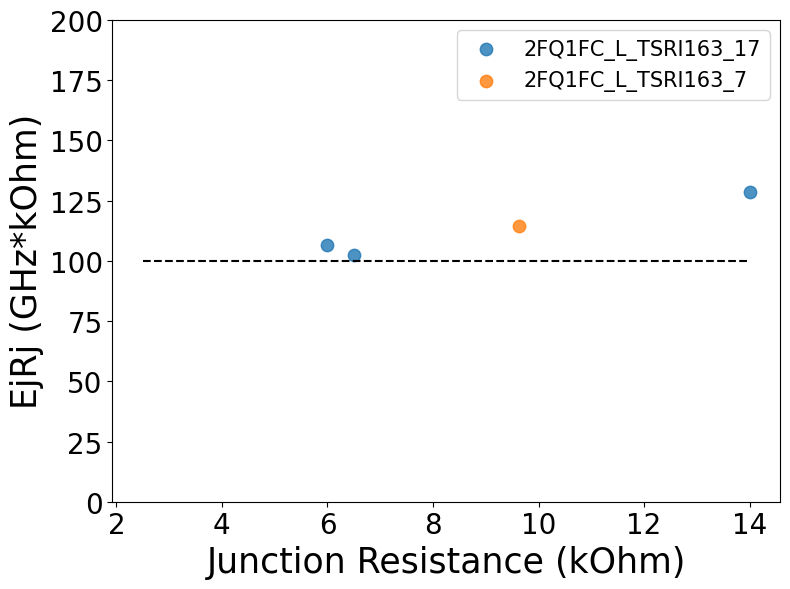

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Junction Resistance", "EjRj", ax)

ax.set_xlabel("Junction Resistance (kOhm)", fontsize=label_fontsize)
ax.set_ylabel("EjRj (GHz*kOhm)", fontsize=label_fontsize)  # Adjust as needed
ax.set_ylim(0,200)

import numpy as np
gap_const = 100
f = np.linspace(2.5, 14, 100)
ax.plot(f, f*0+gap_const, "--",color="black")

ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

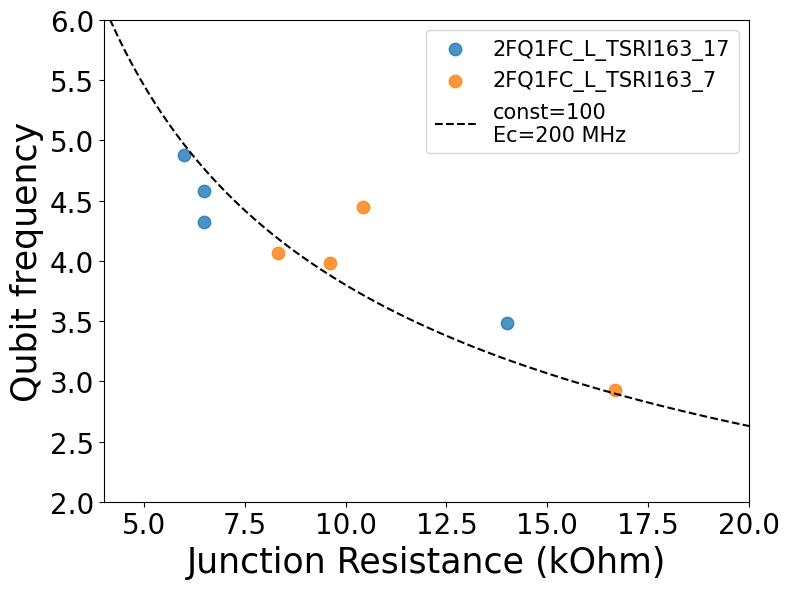

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Junction Resistance", "Qubit frequency", ax)

ax.set_xlabel("Junction Resistance (kOhm)", fontsize=label_fontsize)
ax.set_ylabel("Qubit frequency", fontsize=label_fontsize)  # Adjust as needed
ax.set_ylim(2,10)
# plot decoration
import numpy as np
f = np.linspace(2, 20, 100)
ax.plot(f, np.sqrt(8*gap_const/f*0.2)-0.2, "--",color="black",label=f"const={gap_const}\nEc=200 MHz")
ax.legend(fontsize=legend_fontsize)

ax.set_xlim(4,20)
ax.set_ylim(2,6)

ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

### Plot T1

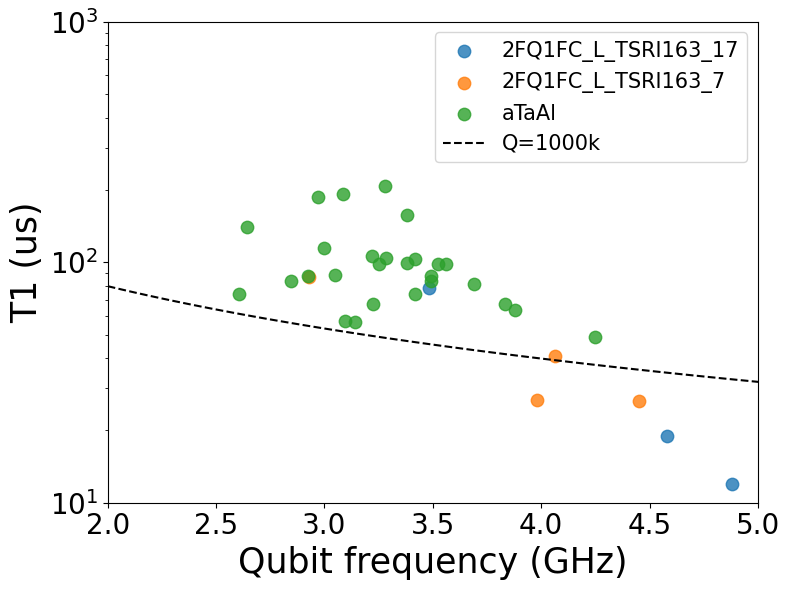

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Qubit frequency", "T1", ax)

ax.set_xlabel("Qubit frequency (GHz)", fontsize=label_fontsize)
ax.set_ylabel("T1 (us)", fontsize=label_fontsize)  # Adjust as needed
# plot decoration
import numpy as np
f = np.linspace(2, 8, 100)
qq = 1000
ax.plot(f, qq/(2*np.pi*f), "--",color="black",label=f"Q={qq}k")
ax.legend(fontsize=legend_fontsize)
ax.set_xlim(2,5)
ax.set_ylim(10,1000)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

### Plot T_other

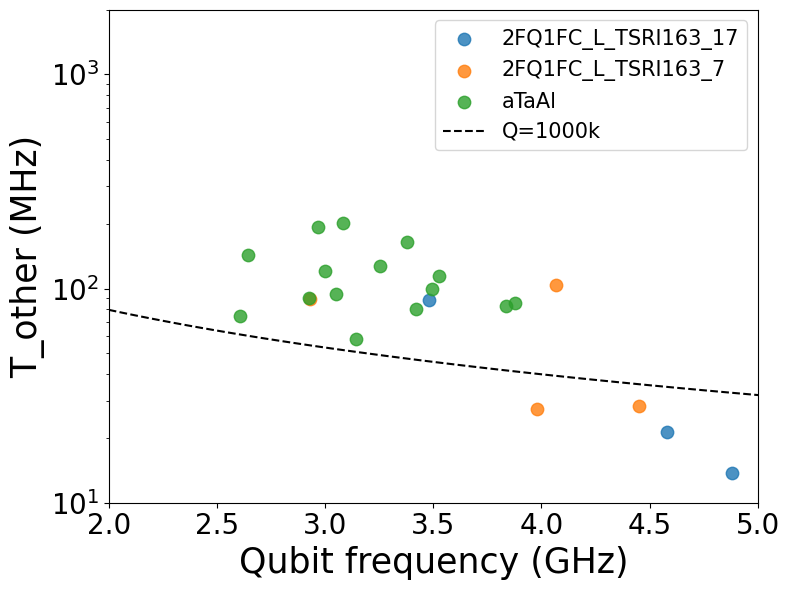

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Qubit frequency", "T_other", ax)

ax.set_xlabel("Qubit frequency (GHz)", fontsize=label_fontsize)
ax.set_ylabel("T_other (MHz)", fontsize=label_fontsize)  # Adjust as needed
# plot decoration
import numpy as np
f = np.linspace(2, 8, 100)
qq = 1000
ax.plot(f, (qq/(2*np.pi*f)), "--",color="black",label=f"Q={qq}k")
ax.legend(fontsize=legend_fontsize)
ax.set_xlim(2,5)
ax.set_ylim(10,2000)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

### Purcell Ratio

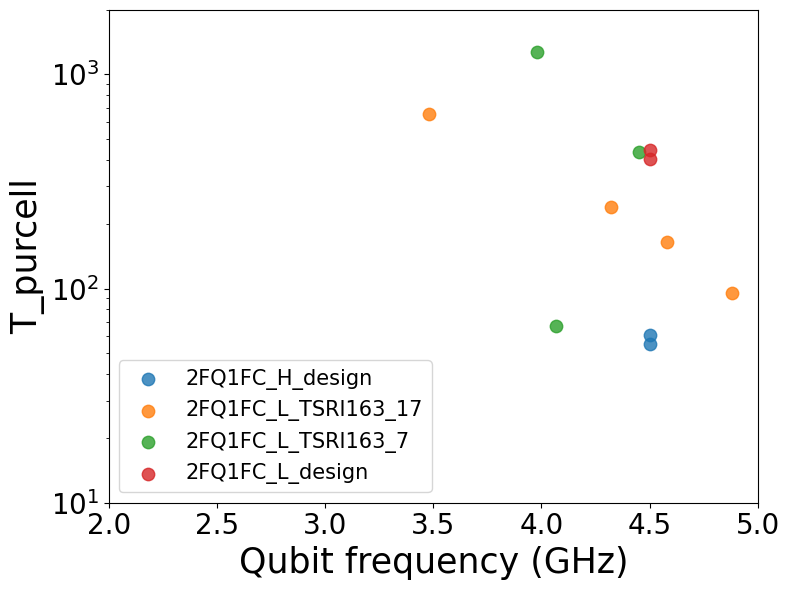

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Qubit frequency", "T_purcell", ax)

ax.set_xlabel("Qubit frequency (GHz)", fontsize=label_fontsize)
ax.set_ylabel("T_purcell", fontsize=label_fontsize)  # Adjust as needed
# plot decoration
import numpy as np
f = np.linspace(2, 8, 100)
qq = 1000
# ax.plot(f, (qq/(2*np.pi*f)), "--",color="black",label=f"Q={qq}k")
ax.legend(fontsize=legend_fontsize)
ax.set_xlim(2,5)
ax.set_ylim(10,2000)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

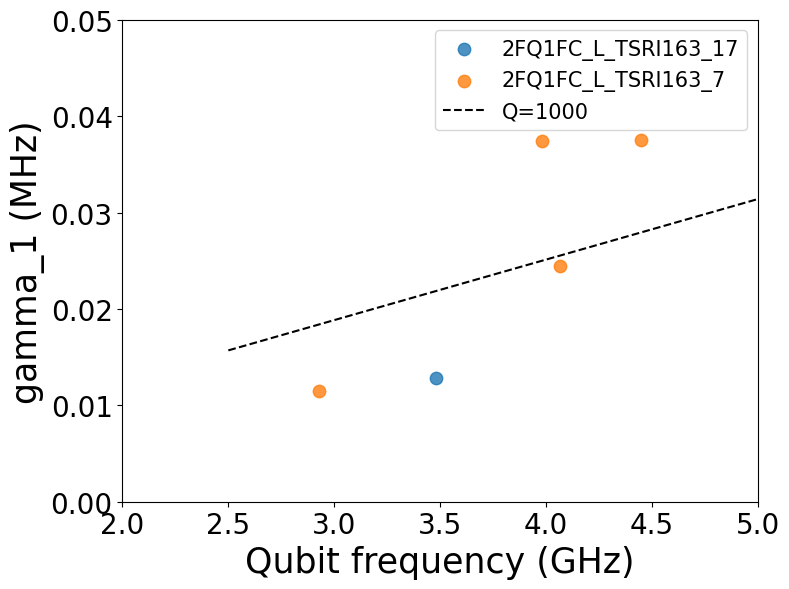

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Qubit frequency", "gamma_1", ax)

ax.set_xlabel("Qubit frequency (GHz)", fontsize=label_fontsize)
ax.set_ylabel("gamma_1 (MHz)", fontsize=label_fontsize)  # Adjust as needed
# plot decoration
import numpy as np
f = np.linspace(2.5, 8, 100)
ax.plot(f, (f*np.pi*2)/qq, "--",color="black",label=f"Q={qq}")
ax.legend(fontsize=legend_fontsize)
ax.set_xlim(2,5)
ax.set_ylim(0,0.05)

ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

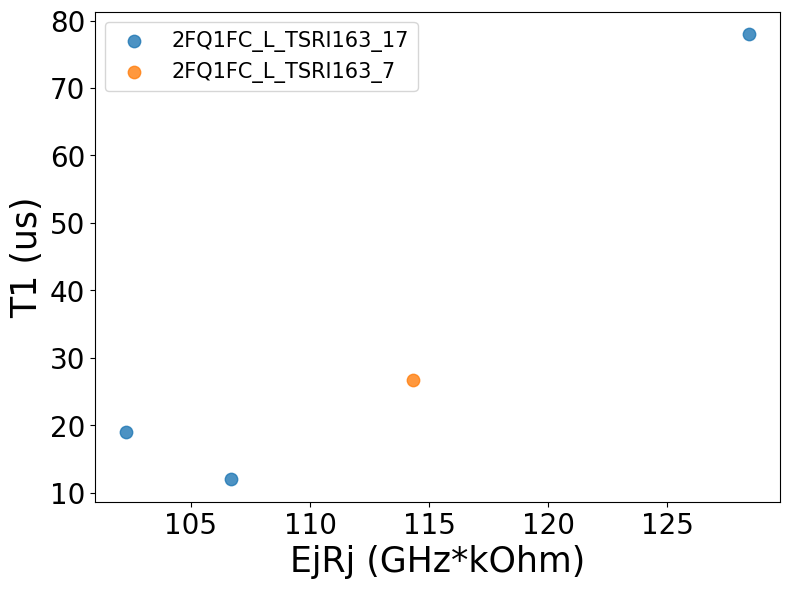

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "EjRj", "T1", ax)

ax.set_xlabel("EjRj (GHz*kOhm)", fontsize=label_fontsize)
ax.set_ylabel("T1 (us)", fontsize=label_fontsize)  # Adjust as needed
# plot decoration
import numpy as np

ax.legend(fontsize=legend_fontsize)
# ax.set_ylim(0,1)

ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

### Plot Ec

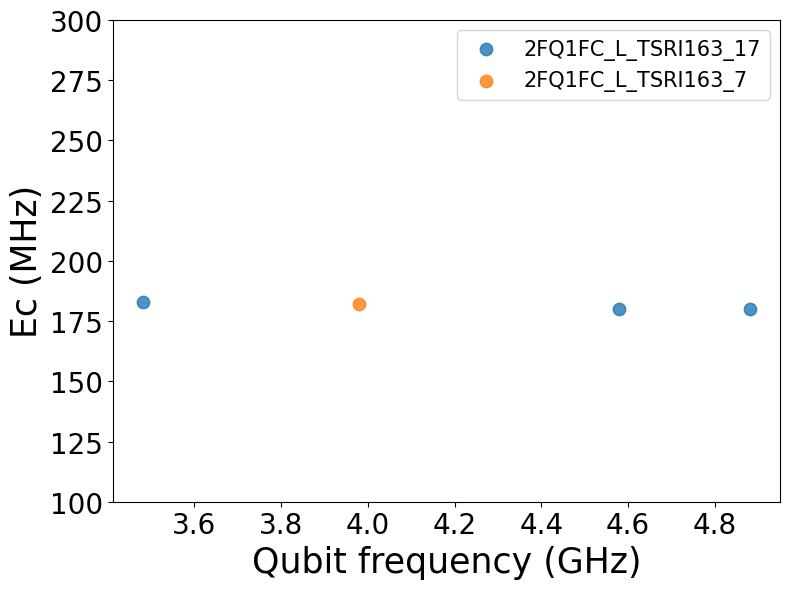

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Qubit frequency", "Ec", ax)

ax.set_xlabel("Qubit frequency (GHz)", fontsize=label_fontsize)
ax.set_ylabel("Ec (MHz)", fontsize=label_fontsize)  # Adjust as needed
ax.set_ylim(100,300)
ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

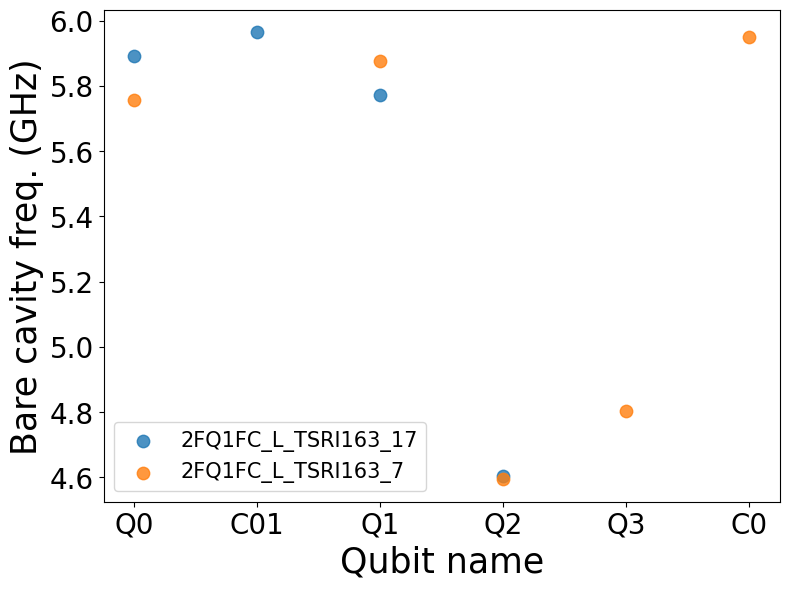

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "name", "Bare resonant frequency", ax)

ax.set_xlabel("Qubit name", fontsize=label_fontsize)
ax.set_ylabel("Bare cavity freq. (GHz)", fontsize=label_fontsize)  # Adjust as needed
# ax.set_ylim(100,300)
ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

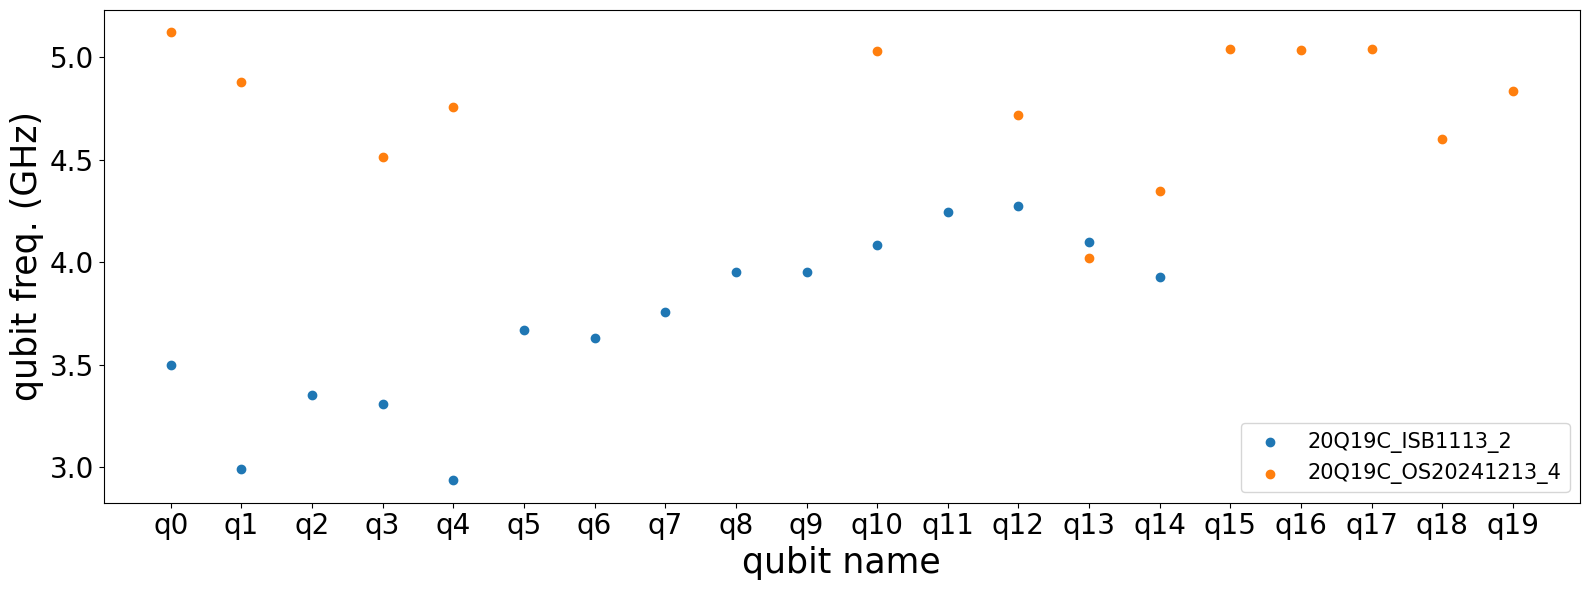

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_scatter_multi(grouped_paras, "name", "Qubit frequency", ax)

ax.set_xlabel("qubit name", fontsize=label_fontsize)
ax.set_ylabel("qubit freq. (GHz)", fontsize=label_fontsize)  # Adjust as needed
# ax.set_ylim(100,300)
ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()


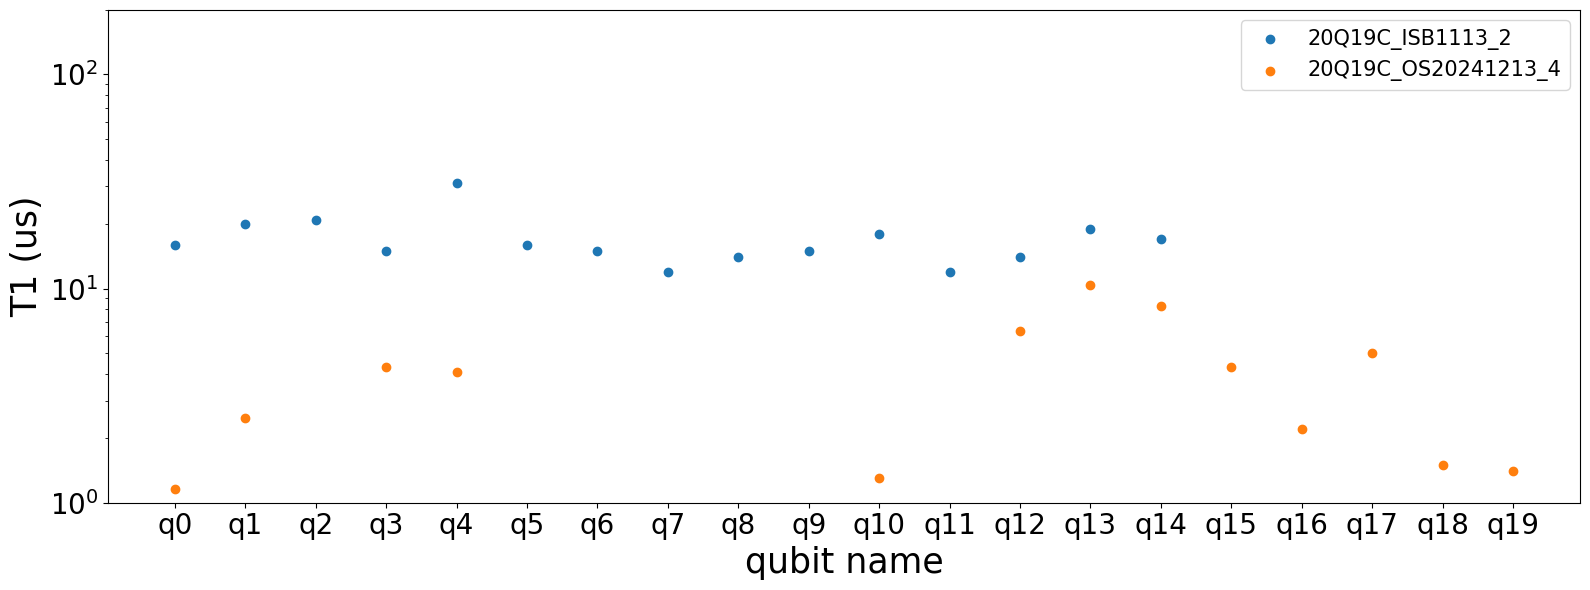

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_scatter_multi(grouped_paras, "name", "T1", ax)

ax.set_xlabel("qubit name", fontsize=label_fontsize)
ax.set_ylabel("T1 (us)", fontsize=label_fontsize)  # Adjust as needed
# ax.set_ylim(100,300)
ax.set_ylim(1,200)
ax.set_yscale('log')
ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

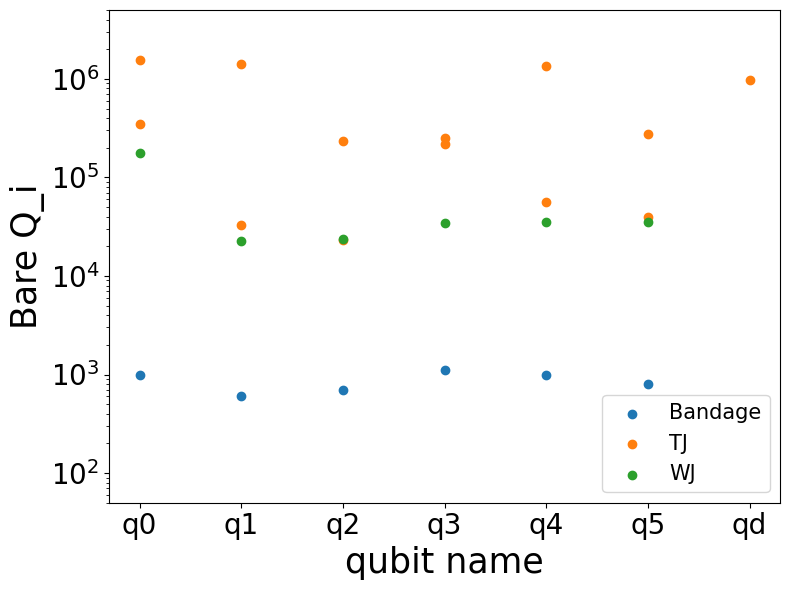

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "name", "Bare Q_i", ax)

ax.set_xlabel("qubit name", fontsize=label_fontsize)
ax.set_ylabel("Bare Q_i", fontsize=label_fontsize)  # Adjust as needed
ax.set_ylim(0.5e2,5e6)
ax.set_yscale("log")
ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

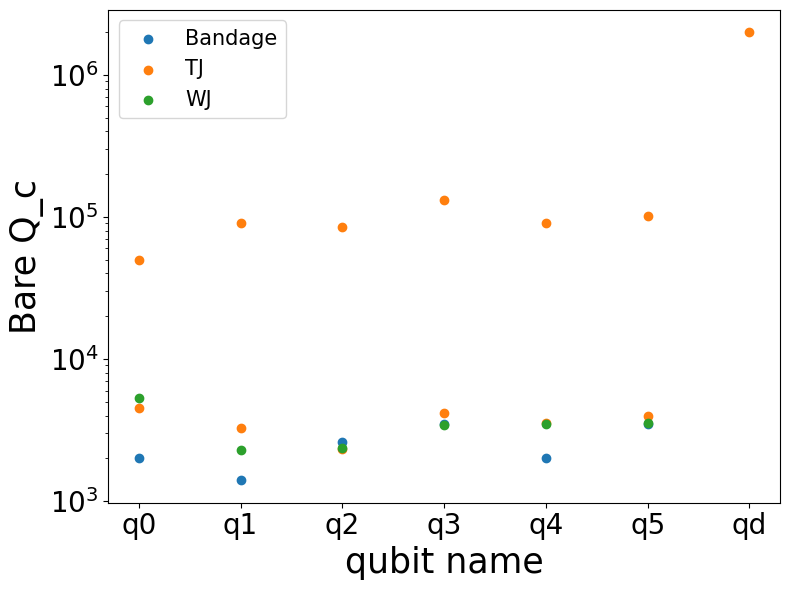

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "name", "Bare Q_c", ax)

ax.set_xlabel("qubit name", fontsize=label_fontsize)
ax.set_ylabel("Bare Q_c", fontsize=label_fontsize)  # Adjust as needed
# ax.set_ylim(0.5e2,5e6)
ax.set_yscale("log")
ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

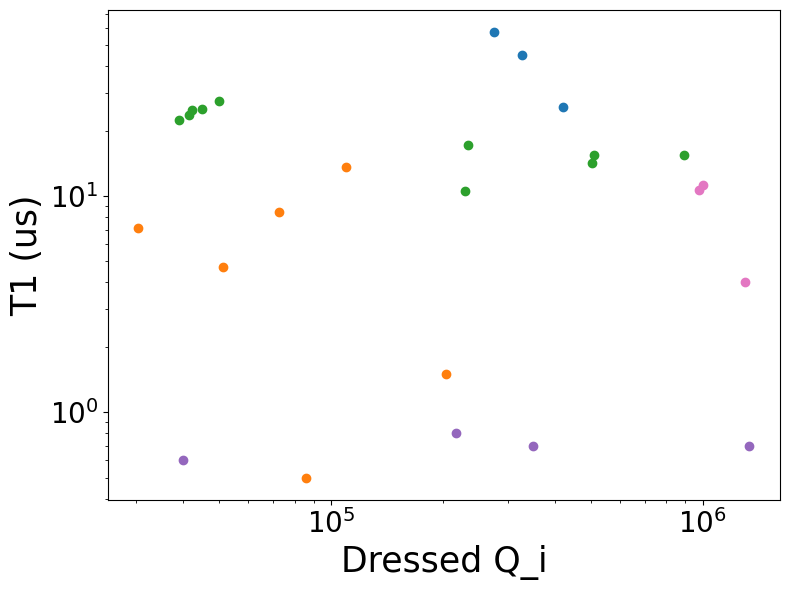

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "Bare Q_i", "T1", ax)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel("Dressed Q_i", fontsize=label_fontsize)
ax.set_ylabel("T1 (us)", fontsize=label_fontsize)  # Adjust as needed
# plot decoration
import numpy as np
# f = np.linspace(2.5, 8, 100)
# qq = 700
# ax.plot(f, qq/(2*np.pi*f), "--",color="black",label=f"Q={qq}k")
# ax.legend(fontsize=legend_fontsize)
# ax.set_ylim(0,2)

ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

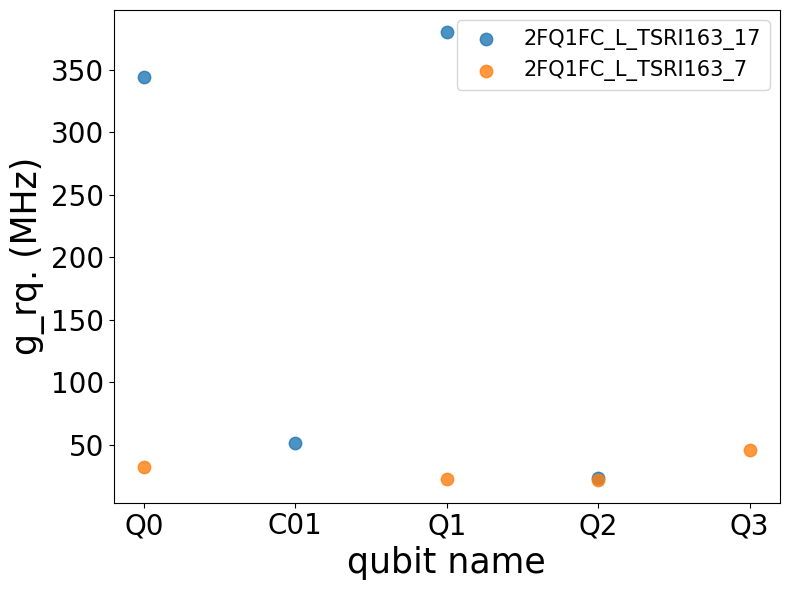

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_scatter_multi(grouped_paras, "name", "g_rq", ax)

ax.set_xlabel("qubit name", fontsize=label_fontsize)
ax.set_ylabel("g_rq. (MHz)", fontsize=label_fontsize)  # Adjust as needed
# ax.set_ylim(100,300)
ax.legend(fontsize=legend_fontsize)
# plot decoration
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

## interactive sheet

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_data)